# Draft sensitivity - hydrodynamic analysis

Analyses the OrcaWave diffraction output of the 8 draft variants
(`Merganser_1.xlsx` ... `Merganser_8.xlsx`, where the file number = draft in m).

For **Heave / Pitch / Roll**:
1. **Displacement RAOs** - motion per unit wave amplitude; peaks give the natural periods.
2. **Added mass / radiation damping vs period** - one line per draft.
3. **Added mass / radiation damping vs draft** - cut at a few periods.
4. **Load (excitation) RAOs** - amplitude vs period, vs draft, and phase.
5. **Hydrostatic stiffness vs draft** - diagonal restoring terms.

> Note: displacement RAOs depend on body mass/inertia. This run uses a placeholder
> inertia (see the diffraction note below), so the peaks only give the *true*
> natural periods once the runs carry the correct structural mass and inertia.

Added mass, radiation damping and load RAOs are all inertia-independent, so they
are valid for this run despite the dummy inertia used in the diffraction step.

## Imports and settings

In [28]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings("ignore")
%matplotlib inline

plt.rcParams.update({
    "font.size": 14, "axes.titlesize": 20, "axes.labelsize": 17,
    "xtick.labelsize": 14, "ytick.labelsize": 14,
    "legend.fontsize": 13, "legend.title_fontsize": 14, "figure.titlesize": 24,
})

# =========================================================================
#  EDIT HERE
# =========================================================================
XLSX_DIR = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Rhino\Draft sensitivity\XLSX_results")

DRAFTS = [1, 2, 3, 4, 5,6,7,8]   # m, matches Merganser_<i>.xlsx
DATASETS = {XLSX_DIR / f"Merganser_{d}.xlsx": f"Draft {d} m" for d in DRAFTS}

# Sequential colours: light = shallow draft, dark = deep draft.
COLORS = [plt.cm.viridis(x) for x in np.linspace(0.05, 0.95, len(DATASETS))]

# DOFs to plot, in this order. Value = 0-based diagonal index (Surge=0..Yaw=5).
DOFS = [("Heave", 2), ("Pitch", 4), ("Roll", 3)]

# Rotational radiation damping is exported per rad/s; divide by this for per deg/s.
RAD2DEG = 180.0 / np.pi   # = 57.2958

# Periods at which to cut the "vs draft" sensitivity plots [s].
# Default list, used for any DOF without an explicit override below.
PERIODS_OF_INTEREST = [4.1, 8.4]

# Optional per-DOF override of the periods of interest.
# Key = DOF name (as in DOFS); value = list of periods [s].
# A DOF missing here falls back to PERIODS_OF_INTEREST, so you can give each
# DOF its own resonance / period of interest (e.g. heave vs pitch vs roll).
PERIODS_OF_INTEREST_BY_DOF = {
    "Heave": [4.1, 8.4],
    "Pitch": [4.1, 8.4],
    "Roll":  [4.1, 8.4],
}

# Draw the periods of interest as vertical guide lines on the "vs period" plots.
SHOW_POI_LINES = True

# Load-RAO sheet: "Load RAOs (diffraction)" (direct) or "Load RAOs (Haskind)"
# (cross-check via the radiation potentials; should match closely).
RAO_SHEET = "Load RAOs (diffraction)"

# Where the figures are saved.
FIG_DIR = XLSX_DIR.parent / "DA_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Reading the data

**Added mass / Damping** are stored as blocks: one 6x6 DOF matrix per period.
Each block starts with a marker (`... for period X,Ys`) in column 1; the matrix
begins 5 rows below it. We take the diagonal terms (the direct added mass /
damping for each own degree of freedom).

In [29]:
def read_matrix_sheet(xlsx, sheet):
    """Read 'Added mass'/'Damping' from one file. Returns (periods, diag[n, 6])."""
    df = pd.read_excel(xlsx, sheet_name=sheet, header=None)

    periods, diag = [], []
    for i in range(df.shape[0]):
        marker = df.iat[i, 1] if df.shape[1] > 1 else None
        if isinstance(marker, str) and "period" in marker.lower():
            txt = marker.lower().split("period")[-1].replace("s", "").strip()
            period = float(txt.replace(",", "."))          # NL comma -> dot
            block = df.iloc[i + 5 : i + 11, 1:7].to_numpy(dtype=float)
            periods.append(period)
            diag.append(np.diag(block))

    order = np.argsort(periods)
    return np.array(periods)[order], np.array(diag)[order]


def read_all(sheet):
    """Read one sheet for every dataset once. Returns {name: (periods, diag)}."""
    return {name: read_matrix_sheet(path, sheet) for path, name in DATASETS.items()}



def periods_for(dof_name):
    """Periods of interest for a DOF: per-DOF override, else the global default."""
    return PERIODS_OF_INTEREST_BY_DOF.get(dof_name, PERIODS_OF_INTEREST)


## View 1 - displacement RAOs (natural periods)

Motion per unit wave amplitude, one line per draft. The peak of each curve is the
natural period of that DOF. Translations are in m/m, rotations converted rad/m ->
**deg/m**. A peak marker (v) is drawn only when the maximum is *inside* the period
grid; a peak at the grid edge means the resonance lies outside the modelled range.

**Caveat:** displacement RAOs depend on (M + A). The diffraction run uses a
placeholder inertia, so read the natural periods here only once the runs carry the
correct structural mass and inertia. Otherwise use `T_n = 2*pi*sqrt((M+A)/C)` with
the added mass (View 2) and hydrostatic stiffness (View 5), which are inertia-free.

In [30]:
def read_displacement_rao(xlsx, sheet="Displacement RAOs"):
    """Displacement RAOs for the single wave heading in the file.
    Returns (periods, ampl[n, 6], phase[n, 6]); DOF order Surge..Yaw.
    Amplitude units: m/m (translation), rad/m (rotation)."""
    df = pd.read_excel(xlsx, sheet_name=sheet, header=None)

    periods, ampl, phase = [], [], []
    for i in range(df.shape[0]):
        try:
            h = float(str(df.iat[i, 0]).replace(",", "."))   # wave heading
            T = float(str(df.iat[i, 1]).replace(",", "."))   # period
        except (ValueError, TypeError):
            continue
        if not (np.isfinite(h) and np.isfinite(T)):          # skip header rows
            continue
        a = [float(str(df.iat[i, 2 + 2 * k]).replace(",", ".")) for k in range(6)]
        p = [float(str(df.iat[i, 3 + 2 * k]).replace(",", ".")) for k in range(6)]
        periods.append(T); ampl.append(a); phase.append(p)

    order = np.argsort(periods)
    return np.array(periods)[order], np.array(ampl)[order], np.array(phase)[order]


def read_all_disp_rao():
    return {name: read_displacement_rao(path) for path, name in DATASETS.items()}

In [31]:
def plot_disp_rao_vs_period(title="Displacement RAO vs period"):
    """Displacement RAO amplitude vs period, one line per draft.
    Rotations converted rad/m -> deg/m. Peak markers are drawn only for interior
    maxima (resonance captured within the modelled period range)."""
    series = read_all_disp_rao()
    fig, axes = plt.subplots(1, len(DOFS), figsize=(18, 6))
    for ax, (dof_name, idx) in zip(axes, DOFS):
        for c, (name, (periods, ampl, phase)) in zip(COLORS, series.items()):
            y = ampl[:, idx] / (RAD2DEG if idx in (3, 4, 5) else 1.0)  # rad/m -> deg/m
            ax.plot(periods, y, lw=2.2, color=c, label=name)
            k = int(np.argmax(y))
            if 0 < k < len(periods) - 1:          # interior peak = resonance in range
                ax.plot(periods[k], y[k], marker="v", ms=9, color=c,
                        markeredgecolor="k", markeredgewidth=0.6, zorder=5)
        unit = "deg/m" if idx in (3, 4, 5) else "m/m"
        ax.set_title(dof_name, fontweight="bold")
        ax.set_xlabel("Period [s]")
        ax.set_ylabel(f"Displacement RAO [{unit}]")
  
        ax.grid(True, alpha=0.3)
        ax.tick_params(width=1.2, length=6)
        ax.legend(title="Draft")
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig


def natural_periods_table():
    """Natural period [s] per draft per DOF, read from the displacement-RAO peak.
    A trailing '*' flags a peak at the grid edge (resonance outside the range)."""
    series = read_all_disp_rao()
    rows = []
    for name, (periods, ampl, phase) in series.items():
        row = {"Draft": name}
        for dof_name, idx in DOFS:
            y = ampl[:, idx]
            k = int(np.argmax(y))
            edge = (k == 0 or k == len(periods) - 1)
            row[dof_name] = f"{periods[k]:.2f}" + ("*" if edge else "")
        rows.append(row)
    return pd.DataFrame(rows).set_index("Draft")

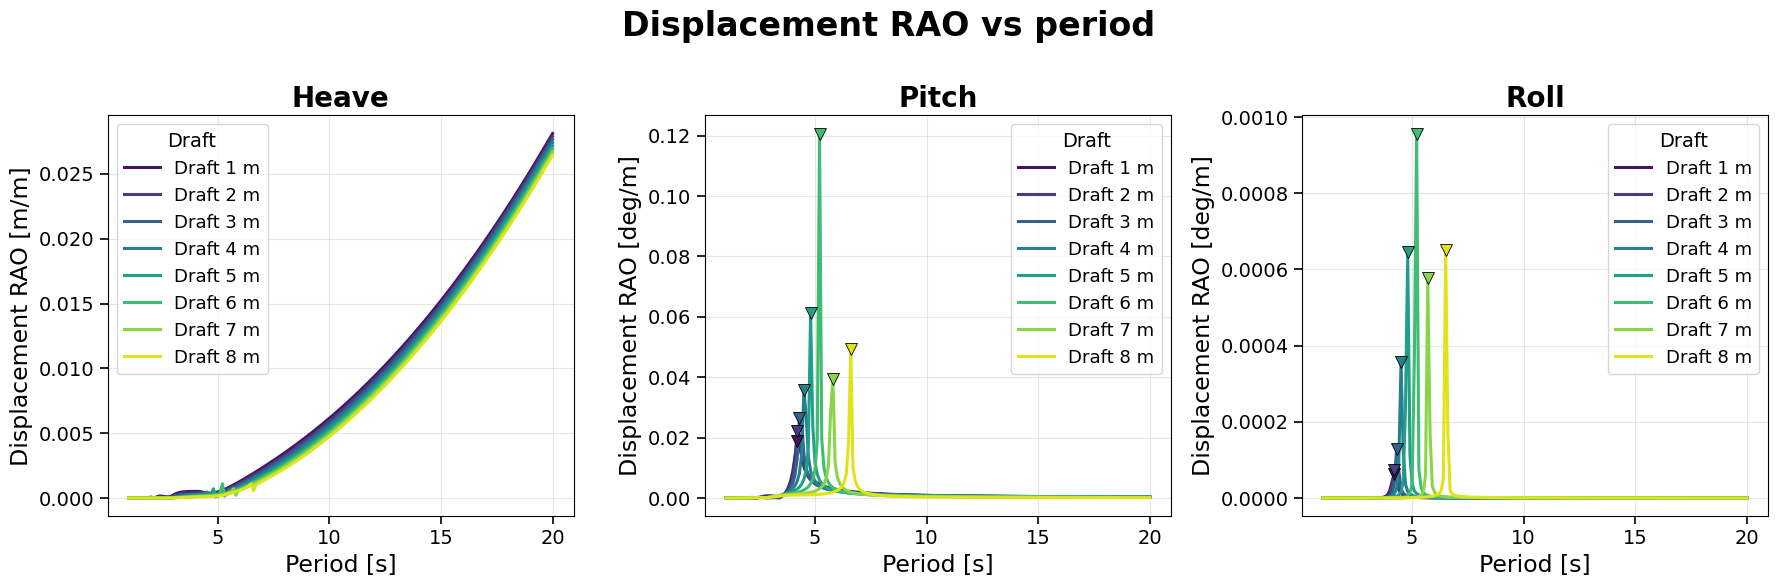

Natural period [s] from displacement-RAO peak (* = peak at grid edge, true resonance outside modelled range):
            Heave Pitch  Roll
Draft                        
Draft 1 m  20.00*  4.20  4.20
Draft 2 m  20.00*  4.20  4.20
Draft 3 m  20.00*  4.30  4.30
Draft 4 m  20.00*  4.50  4.50
Draft 5 m  20.00*  4.80  4.80
Draft 6 m  20.00*  5.20  5.20
Draft 7 m  20.00*  5.80  5.70
Draft 8 m  20.00*  6.60  6.50


In [32]:
fig = plot_disp_rao_vs_period("Displacement RAO vs period")
fig.savefig(FIG_DIR / "0_displacement_rao_vs_period.png", dpi=150, bbox_inches="tight")
plt.show()

print("Natural period [s] from displacement-RAO peak "
      "(* = peak at grid edge, true resonance outside modelled range):")
print(natural_periods_table().to_string())

## View 2 - coefficient vs period (one line per draft)

In [33]:
def plot_vs_period(sheet, title, ylabel1, ylabel2):
    series = read_all(sheet)
    is_damping = sheet == "Damping"

    fig, axes = plt.subplots(1, len(DOFS), figsize=(18, 6))
    for ax, (dof_name, idx) in zip(axes, DOFS):
        for c, (name, (periods, diag)) in zip(COLORS, series.items()):
            y = diag[:, idx]
            if is_damping and idx in (3, 4, 5):      # rad/s -> deg/s for rotations
                y = y / RAD2DEG
            ax.plot(periods, y, lw=2.2, color=c, label=name)
        if SHOW_POI_LINES:
            for T in periods_for(dof_name):
                ax.axvline(T, color="0.4", ls="--", lw=1.2, alpha=0.7, zorder=0)
        ax.set_title(dof_name, fontweight="bold")
        ax.set_xlabel("Period [s]")
        ax.set_ylabel(ylabel1 if ax == axes[0] else ylabel2)
        ax.grid(True, alpha=0.3)
        ax.tick_params(width=1.2, length=6)
        ax.legend(title="Draft")
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig

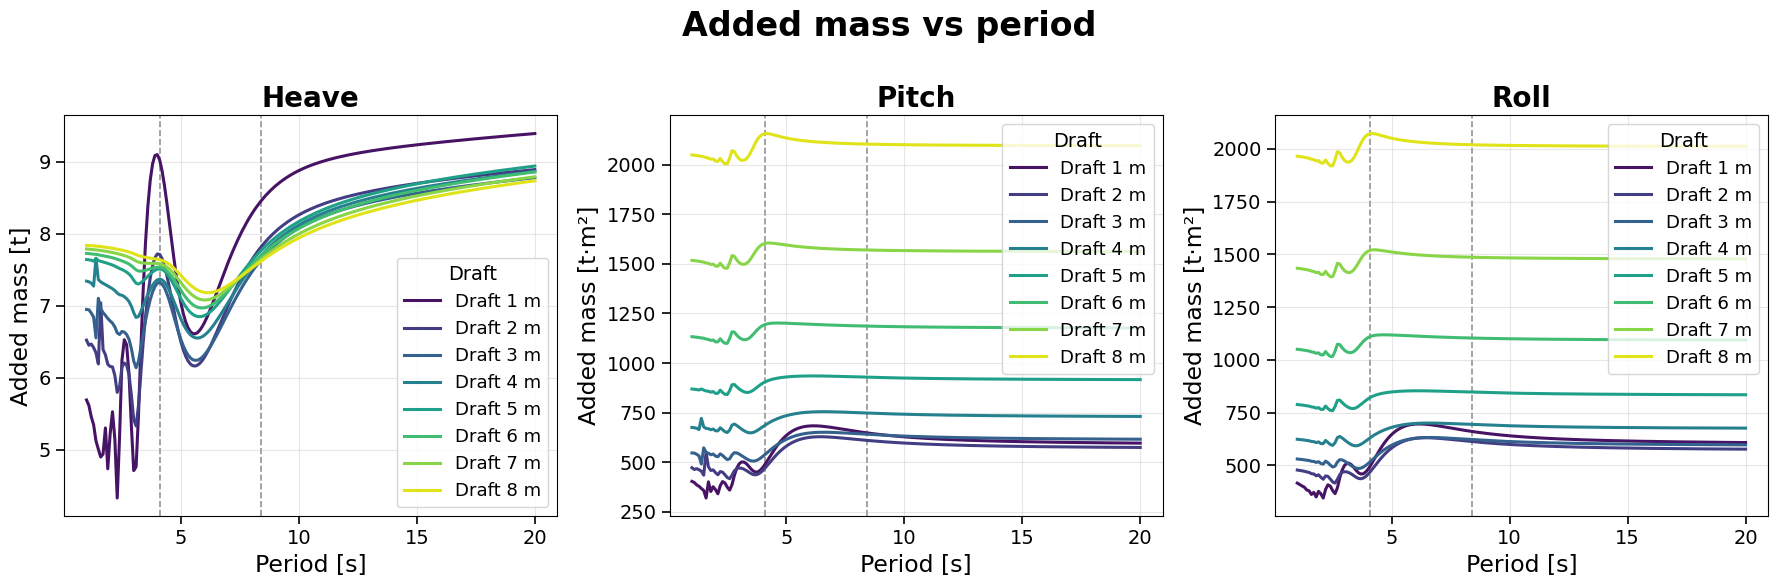

In [34]:
fig = plot_vs_period(
    "Added mass", "Added mass vs period",
    "Added mass [t]", "Added mass [t·m²]",
)
fig.savefig(FIG_DIR / "1_added_mass_vs_period.png", dpi=150, bbox_inches="tight")
plt.show()

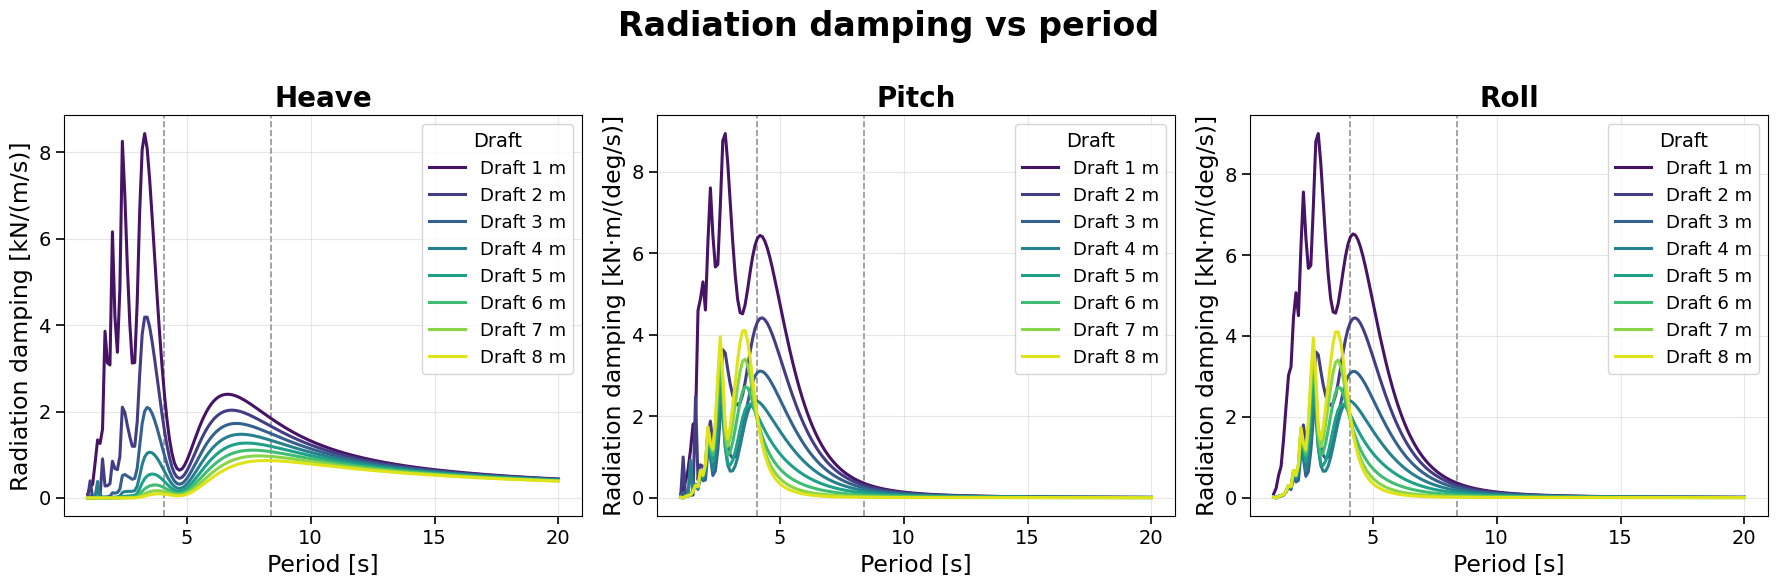

In [35]:
fig = plot_vs_period(
    "Damping", "Radiation damping vs period",
    "Radiation damping [kN/(m/s)]", "Radiation damping [kN·m/(deg/s)]",
)
fig.savefig(FIG_DIR / "2_damping_vs_period.png", dpi=150, bbox_inches="tight")
plt.show()

## View 3 - coefficient vs draft (one line per period)

For each period in `PERIODS_OF_INTEREST` the coefficient is interpolated from the
dense period grid, then plotted against draft. This shows directly how strongly
each coefficient responds to draft.

In [36]:
def plot_vs_draft(sheet, title, ylabel1, ylabel2):
    series = read_all(sheet)
    names = list(DATASETS.values())
    is_damping = sheet == "Damping"

    fig, axes = plt.subplots(1, len(DOFS), figsize=(18, 6))
    for ax, (dof_name, idx) in zip(axes, DOFS):
        for T in periods_for(dof_name):
            ys = []
            for name in names:
                periods, diag = series[name]
                val = np.interp(T, periods, diag[:, idx])
                if is_damping and idx in (3, 4, 5):  # rad/s -> deg/s for rotations
                    val = val / RAD2DEG
                ys.append(val)
            ax.plot(DRAFTS, ys, marker="o", lw=2.0, label=f"{T:g} s")
        ax.set_title(dof_name, fontweight="bold")
        ax.set_xlabel("Draft [m]")
        ax.set_ylabel(ylabel1 if ax == axes[0] else ylabel2)
        ax.grid(True, alpha=0.3)
        ax.tick_params(width=1.2, length=6)
        ax.legend(title="Period")
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig

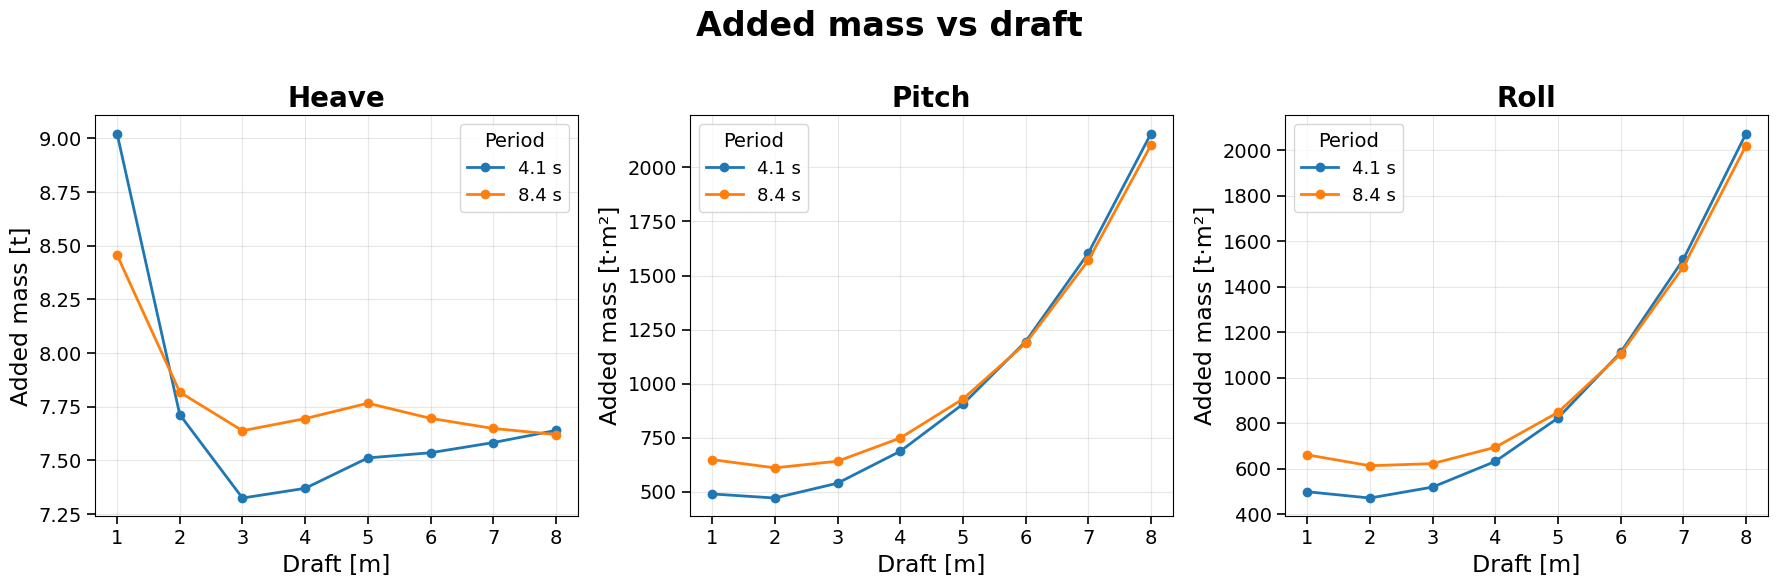

In [37]:
fig = plot_vs_draft(
    "Added mass", "Added mass vs draft",
    "Added mass [t]", "Added mass [t·m²]",
)
fig.savefig(FIG_DIR / "3_added_mass_vs_draft.png", dpi=150, bbox_inches="tight")
plt.show()

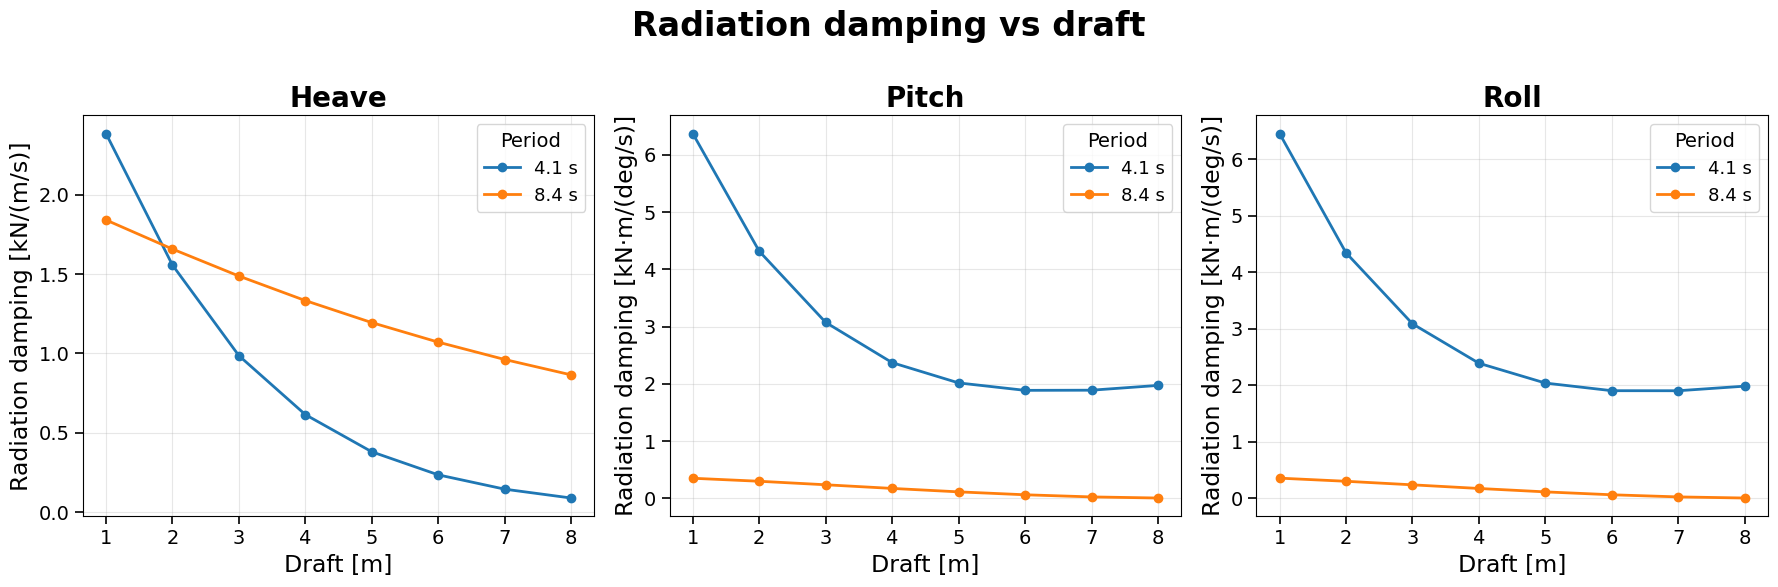

In [38]:
fig = plot_vs_draft(
    "Damping", "Radiation damping vs draft",
    "Radiation damping [kN/(m/s)]", "Radiation damping [kN·m/(deg/s)]",
)
fig.savefig(FIG_DIR / "4_damping_vs_draft.png", dpi=150, bbox_inches="tight")
plt.show()

## View 4 - load (excitation) RAOs

Wave excitation force / moment per unit wave amplitude. These come from the
diffraction problem and are **independent of body inertia**, so they are valid
for this run despite the dummy inertia used in the diffraction calculation.

Only one wave heading (0 deg, head seas) was computed. At 0 deg the **roll**
excitation is near zero by symmetry, so the roll curves will be tiny - that is
physical, not a parsing error.

In [39]:
def read_load_rao(xlsx, sheet=None):
    """Load (excitation) RAOs for the single wave heading in the file.
    Returns (periods, ampl[n, 6], phase[n, 6]); DOF order Surge..Yaw.
    Amplitude units: kN/m (translation), kN.m/m (rotation)."""
    sheet = sheet or RAO_SHEET
    df = pd.read_excel(xlsx, sheet_name=sheet, header=None)

    periods, ampl, phase = [], [], []
    for i in range(df.shape[0]):
        try:
            h = float(str(df.iat[i, 0]).replace(",", "."))   # wave heading
            T = float(str(df.iat[i, 1]).replace(",", "."))   # period
        except (ValueError, TypeError):
            continue
        if not (np.isfinite(h) and np.isfinite(T)):          # skip header rows
            continue
        a = [float(str(df.iat[i, 2 + 2 * k]).replace(",", ".")) for k in range(6)]
        p = [float(str(df.iat[i, 3 + 2 * k]).replace(",", ".")) for k in range(6)]
        periods.append(T); ampl.append(a); phase.append(p)

    order = np.argsort(periods)
    return np.array(periods)[order], np.array(ampl)[order], np.array(phase)[order]


def read_all_rao(sheet=None):
    return {name: read_load_rao(path, sheet) for path, name in DATASETS.items()}


def _rao_unit(idx):
    return "kN/m" if idx in (0, 1, 2) else "kN·m/m"

In [40]:
def plot_rao_vs_period(title, value="amplitude"):
    """value = 'amplitude' or 'phase'. One line per draft."""
    series = read_all_rao()
    fig, axes = plt.subplots(1, len(DOFS), figsize=(18, 6))
    for ax, (dof_name, idx) in zip(axes, DOFS):
        for c, (name, (periods, ampl, phase)) in zip(COLORS, series.items()):
            y = ampl[:, idx] if value == "amplitude" else phase[:, idx]
            ax.plot(periods, y, lw=2.2, color=c, label=name)
        ax.set_title(dof_name, fontweight="bold")
        ax.set_xlabel("Period [s]")
        if value == "amplitude":
            ax.set_ylabel(f"Load RAO amplitude [{_rao_unit(idx)}]")
        else:
            ax.set_ylabel("Load RAO phase [deg]")
        ax.grid(True, alpha=0.3)
        ax.tick_params(width=1.2, length=6)
        ax.legend(title="Draft")
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig


def plot_rao_vs_draft(title):
    """Load RAO amplitude vs draft, one line per period of interest."""
    series = read_all_rao()
    names = list(DATASETS.values())
    fig, axes = plt.subplots(1, len(DOFS), figsize=(18, 6))
    for ax, (dof_name, idx) in zip(axes, DOFS):
        for T in periods_for(dof_name):
            ys = [np.interp(T, series[name][0], series[name][1][:, idx]) for name in names]
            ax.plot(DRAFTS, ys, marker="o", lw=2.0, label=f"{T:g} s")
        ax.set_title(dof_name, fontweight="bold")
        ax.set_xlabel("Draft [m]")
        ax.set_ylabel(f"Load RAO amplitude [{_rao_unit(idx)}]")
        ax.grid(True, alpha=0.3)
        ax.tick_params(width=1.2, length=6)
        ax.legend(title="Period")
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig

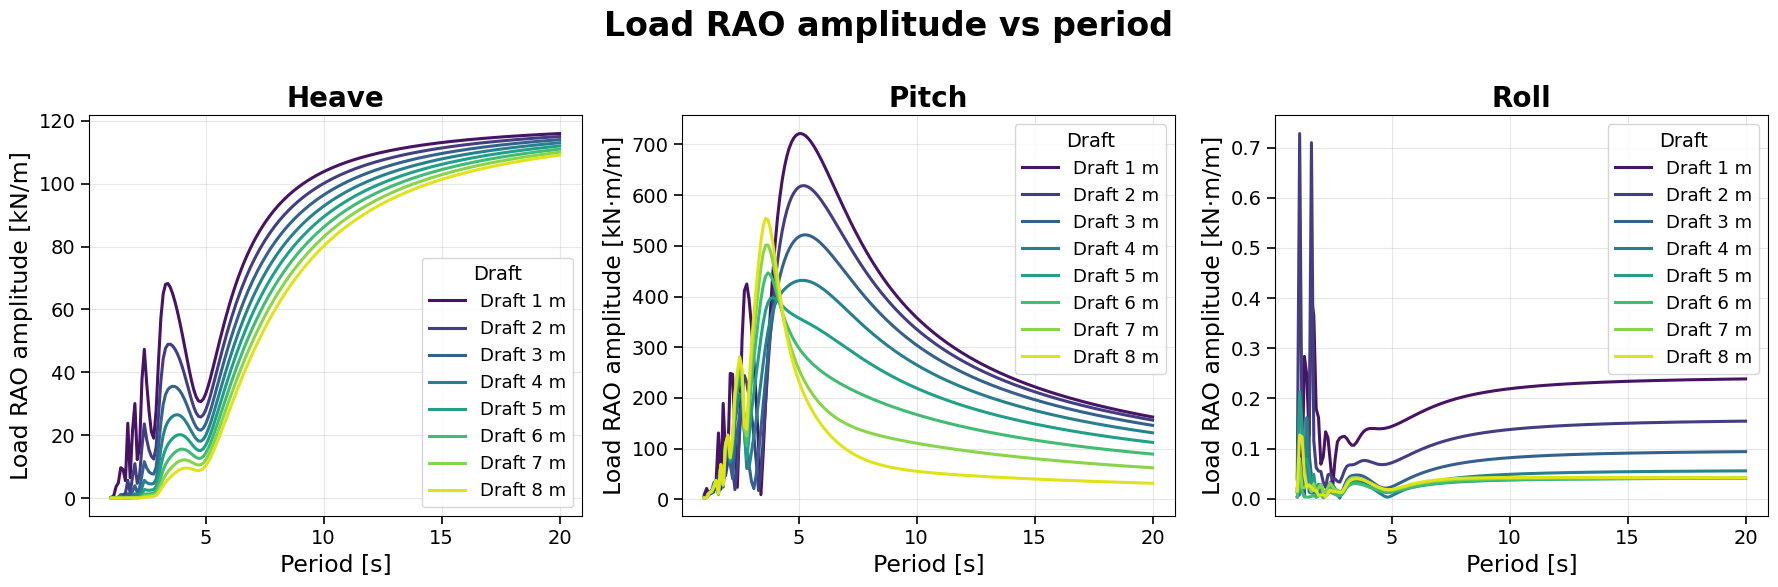

In [41]:
fig = plot_rao_vs_period("Load RAO amplitude vs period", "amplitude")
fig.savefig(FIG_DIR / "5_load_rao_ampl_vs_period.png", dpi=150, bbox_inches="tight")
plt.show()

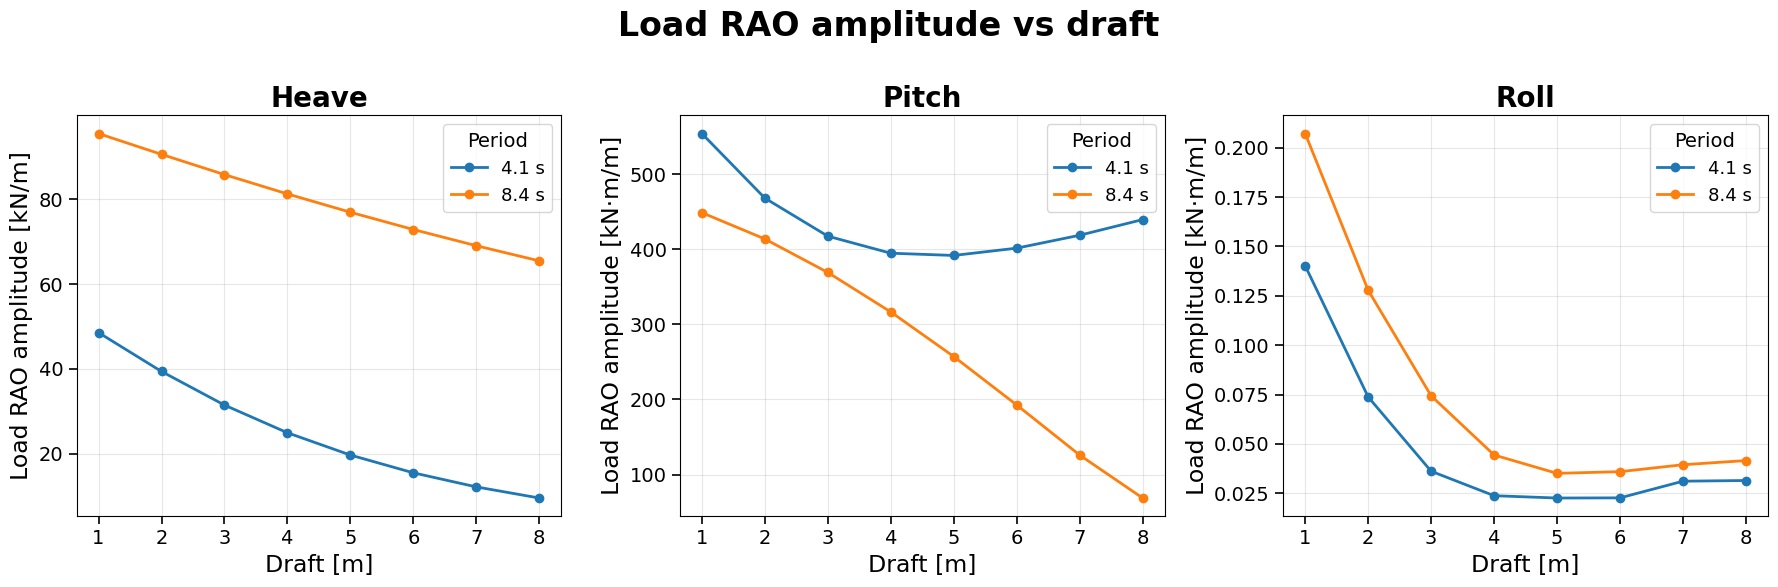

In [42]:
fig = plot_rao_vs_draft("Load RAO amplitude vs draft")
fig.savefig(FIG_DIR / "6_load_rao_ampl_vs_draft.png", dpi=150, bbox_inches="tight")
plt.show()

In [43]:
# # fig = plot_rao_vs_period("Load RAO phase vs period", "phase")
# fig.savefig(FIG_DIR / "7_load_rao_phase_vs_period.png", dpi=150, bbox_inches="tight")
# plt.show()

## View 5 - hydrostatic stiffness vs draft

Diagonal of the 6x6 hydrostatic stiffness matrix on the `Hydrostatics` sheet,
one point per draft. Heave is the linear restoring term (rho*g*A_wp, in kN/m);
roll and pitch are the rotational restoring terms, exported per radian and
converted here to **kN.m/deg** to match the deg convention used elsewhere.

In [44]:
def read_hydrostatic_stiffness(xlsx, sheet="Hydrostatics"):
    """Diagonal of the 6x6 hydrostatic stiffness matrix from one file.
    Export units: translations kN/m, rotations kN.m/rad. DOF order Surge..Yaw."""
    df = pd.read_excel(xlsx, sheet_name=sheet, header=None)
    for i in range(df.shape[0]):
        marker = df.iat[i, 0] if df.shape[1] > 0 else None
        if isinstance(marker, str) and "hydrostatic stiffness" in marker.lower():
            block = df.iloc[i : i + 6, 1:7].to_numpy(dtype=float)
            return np.diag(block)
    raise ValueError(f"Hydrostatic stiffness matrix not found in {xlsx}")


def read_all_stiffness():
    return {name: read_hydrostatic_stiffness(path) for path, name in DATASETS.items()}

In [45]:
def plot_stiffness_vs_draft(title="Hydrostatic stiffness vs draft"):
    """Diagonal hydrostatic stiffness vs draft, one point per draft, per DOF.
    Rotational terms converted kN.m/rad -> kN.m/deg to match the deg convention."""
    series = read_all_stiffness()
    names = list(DATASETS.values())

    fig, axes = plt.subplots(1, len(DOFS), figsize=(18, 6))
    for ax, (dof_name, idx) in zip(axes, DOFS):
        ys = []
        for name in names:
            val = series[name][idx]
            if idx in (3, 4, 5):                 # kN.m/rad -> kN.m/deg for rotations
                val = val / RAD2DEG
            ys.append(val)
        ax.plot(DRAFTS, ys, marker="o", lw=2.0, color="C0")
        ax.set_title(dof_name, fontweight="bold")
        ax.set_xlabel("Draft [m]")
        unit = "kN/m" if idx in (0, 1, 2) else "kN\u00b7m/deg"
        ax.set_ylabel(f"Hydrostatic stiffness [{unit}]")
        ax.grid(True, alpha=0.3)
        ax.tick_params(width=1.2, length=6)
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig

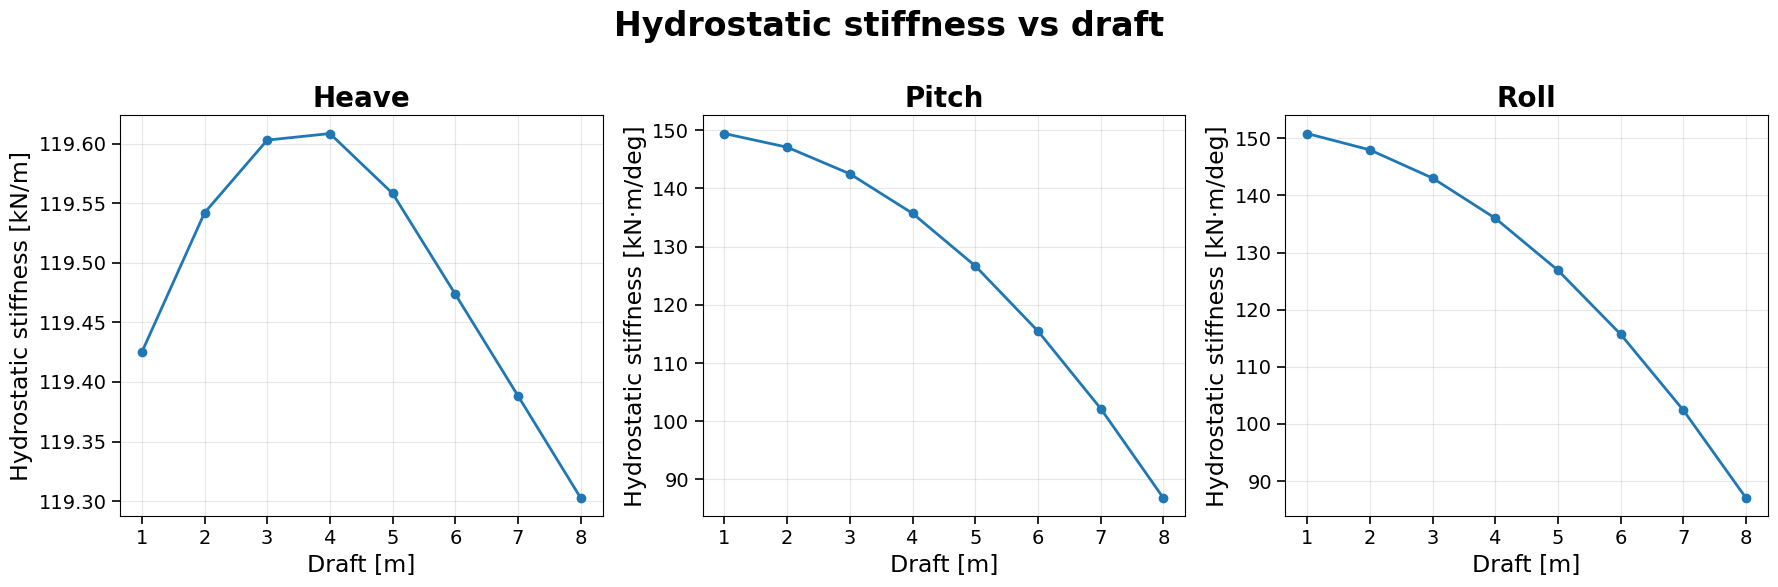

In [46]:
fig = plot_stiffness_vs_draft("Hydrostatic stiffness vs draft")
fig.savefig(FIG_DIR / "8_hydrostatic_stiffness_vs_draft.png", dpi=150, bbox_inches="tight")
plt.show()